# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [1]:
# Replace None with your code
# Imports
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create connection to database
conn = sqlite3.connect('data.sqlite')

### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.

In [2]:
# Replace None with your code
q2 = """
     SELECT customerName, city, state, country, creditLimit
     FROM customers
     WHERE state = 'CA'
       AND country = 'USA'
       AND creditLimit > 25000
     ORDER BY creditLimit DESC; \
     """
ca_customers = pd.read_sql(q2, conn)
ca_customers

,customerName,city,state,country,creditLimit
0,Toys4GrownUps.com,Pasadena,CA,USA,90700.00
1,Technics Stores Inc.,Burlingame,CA,USA,84600.00
2,The Sharp Gifts Warehouse,San Jose,CA,USA,77600.00
3,Mini Wheels Co.,San Francisco,CA,USA,64600.00
4,Signal Collectibles Ltd.,Brisbane,CA,USA,60300.00
5,"Men 'R' US Retailers, Ltd.",Los Angeles,CA,USA,57700.00
6,West Coast Collectables Co.,Burbank,CA,USA,55400.00
7,Mini Gifts Distributors Ltd.,San Rafael,CA,USA,210500.00
8,Boards & Toys Co.,Glendale,CA,USA,11000.00
9,Collectable Mini Designs Co.,San Diego,CA,USA,105000.00


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [3]:
# Replace None with your code
q3 = """
     SELECT customerName, city, country, contactFirstName, contactLastName
     FROM customers
     WHERE country != 'USA'
      AND customerName LIKE '%Collect%'; \
     """
intl_collectables = pd.read_sql(q3, conn)
intl_collectables

,customerName,city,country,contactFirstName,contactLastName
0,"Australian Collectors, Co.",Melbourne,Australia,Peter,Ferguson
1,"Clover Collections, Co.",Dublin,Ireland,Dean,Cassidy
2,"UK Collectables, Ltd.",Liverpool,UK,Elizabeth,Devon
3,"King Kong Collectables, Co.",Central Hong Kong,Hong Kong,Mike,Gao
4,Heintze Collectables,Århus,Denmark,Palle,Ibsen
5,"Royal Canadian Collectables, Ltd.",Tsawassen,Canada,Elizabeth,Lincoln
6,BG&E Collectables,Fribourg,Switzerland,Ed,Harrison
7,Reims Collectables,Reims,France,Paul,Henriot
8,Precious Collectables,Bern,Switzerland,Braun,Urs
9,Salzburg Collectables,Salzburg,Austria,Georg,Pipps


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Type your answer in markdown here!

To filter correctly, the query's `WHERE` clause uses two specific conditions that must both be true:

1. **`country != 'USA'`** - This removes any customers located in the United States, ensuring we only keep international customers from other countries.

2. **`customerName LIKE '%Collect%'`** - This searches for any customer name containing the word "Collect" anywhere in the text. The `%` symbols are wildcards that match any characters before and after "Collect".

The **`AND`** operator means both conditions must be satisfied simultaneously. This ensures we get exactly what was requested: international customers (non-USA) whose company names include "Collect" - perfect for the international collectable marketing campaign.

This filtering approach guarantees data accuracy by eliminating USA customers while precisely targeting companies with collectable-themed names for the marketing campaign.

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [4]:
# Replace None with your code
q4 = """
     SELECT state, AVG(creditLimit) AS avg_credit_limit
     FROM customers
     WHERE country = 'USA'
       AND state IS NOT NULL
     GROUP BY state
     ORDER BY avg_credit_limit DESC; \
     """
usa_credit = pd.read_sql(q4, conn)
usa_credit

,state,avg_credit_limit
0,NH,114200.000000
1,NY,89966.666667
2,PA,84766.666667
3,CA,83854.545455
4,NV,71800.000000
5,MA,70755.555556
6,CT,57350.000000
7,NJ,43000.000000


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

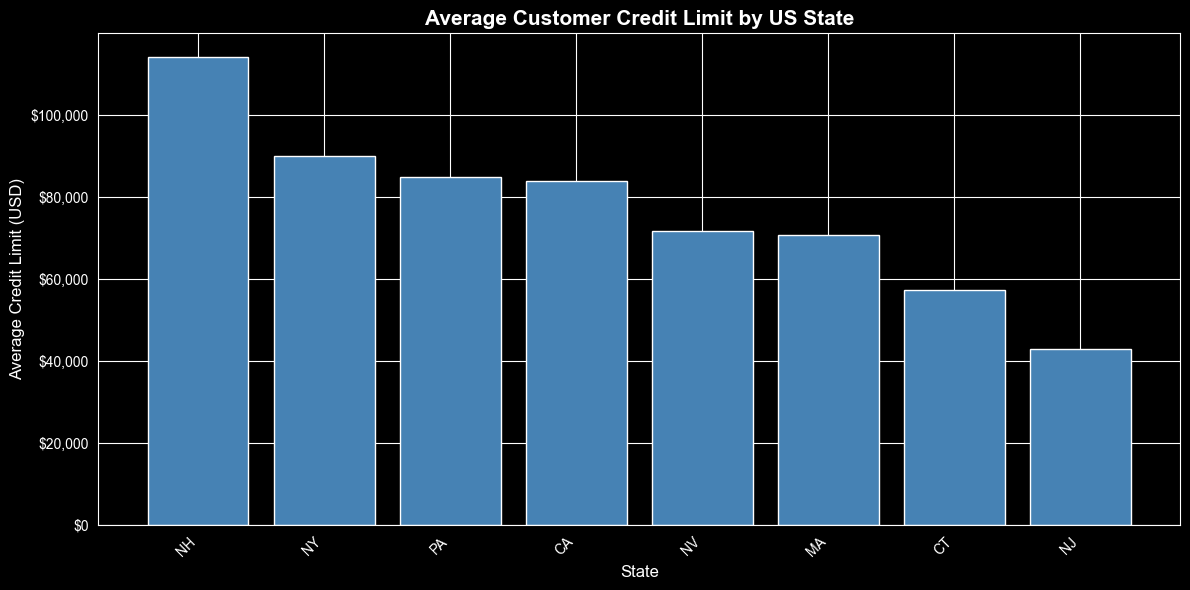

In [5]:
# Replace None with your visual code
# Produce a visual to represent the average credit limit by state
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(usa_credit['state'], usa_credit['avg_credit_limit'], color='steelblue', edgecolor='white')
ax.set_title('Average Customer Credit Limit by US State', fontsize=15, fontweight='bold')
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Average Credit Limit (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [6]:
# Replace None with your code
q5 = """
     SELECT c.customerName, SUM(p.amount) AS total_payments
     FROM customers c
              JOIN payments p ON c.customerNumber = p.customerNumber
     GROUP BY c.customerNumber, c.customerName
     ORDER BY total_payments DESC LIMIT 10; \
     """
top_customers = pd.read_sql(q5, conn)
top_customers

,customerName,total_payments
0,Euro+ Shopping Channel,715738.98
1,Mini Gifts Distributors Ltd.,584188.24
2,"Australian Collectors, Co.",180585.07
3,Muscle Machine Inc,177913.95
4,"Dragon Souveniers, Ltd.",156251.03
5,"Down Under Souveniers, Inc",154622.08
6,"AV Stores, Co.",148410.09
7,"Anna's Decorations, Ltd",137034.22
8,Corporate Gift Ideas Co.,132340.78
9,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

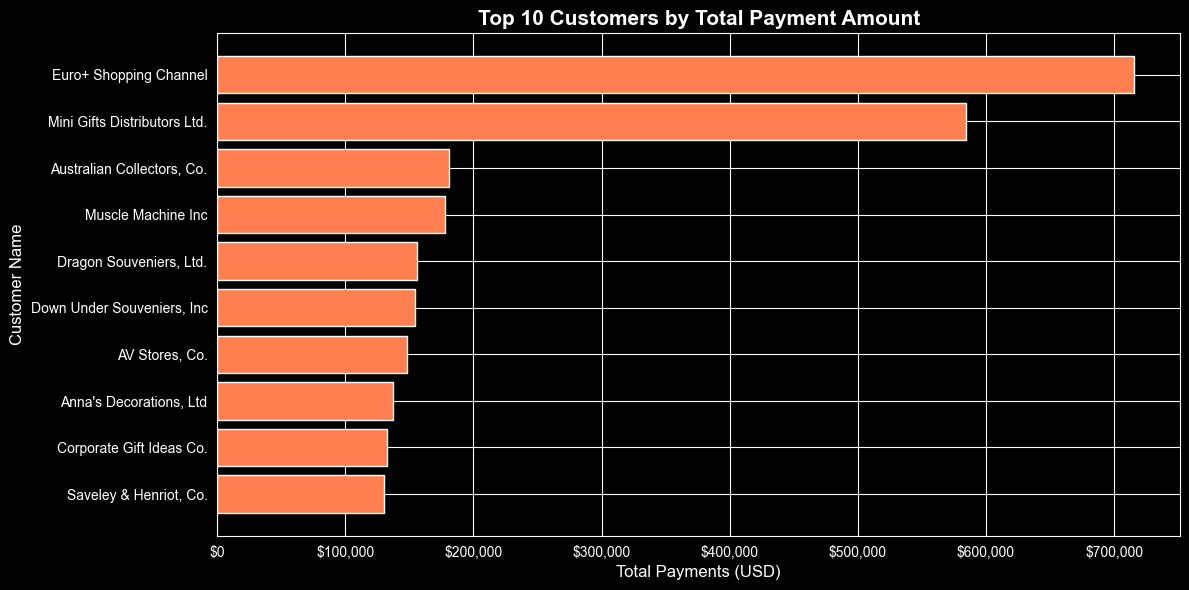

In [7]:
# Replace None with your visual code
# Produce a visual to represent the top ten customers in terms of total payments
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_customers['customerName'][::-1], top_customers['total_payments'][::-1],
        color='coral', edgecolor='white')
ax.set_title('Top 10 Customers by Total Payment Amount', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Payments (USD)', fontsize=12)
ax.set_ylabel('Customer Name', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [8]:
# Replace None with you code
q6 = """
     SELECT c.customerName,
            p.productName,
            SUM(od.quantityOrdered) AS total_quantity
     FROM customers c
              JOIN orders o ON c.customerNumber = o.customerNumber
              JOIN orderdetails od ON o.orderNumber = od.orderNumber
              JOIN products p ON od.productCode = p.productCode
     GROUP BY c.customerNumber, c.customerName, p.productCode, p.productName
     HAVING total_quantity >= 10
     ORDER BY total_quantity ASC; \
     """
cust_product_qty = pd.read_sql(q6, conn)
cust_product_qty

,customerName,productName,total_quantity
0,Petit Auto,1913 Ford Model T Speedster,10
1,"Extreme Desk Decorations, Ltd",1961 Chevrolet Impala,10
2,La Rochelle Gifts,1954 Greyhound Scenicruiser,11
3,Tekni Collectables Inc.,American Airlines: B767-300,11
4,The Sharp Gifts Warehouse,1969 Chevrolet Camaro Z28,13
...,...,...,...
2526,Euro+ Shopping Channel,2002 Chevy Corvette,174
2527,Euro+ Shopping Channel,1957 Chevy Pickup,183
2528,Euro+ Shopping Channel,1970 Dodge Coronet,197
2529,Euro+ Shopping Channel,1958 Chevy Corvette Limited Edition,245


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [9]:
# Replace None with your code
q7 = """
     SELECT pl.productLine,
            COUNT(DISTINCT p.productCode) AS num_products,
            SUM(od.quantityOrdered)       AS total_quantity_ordered
     FROM productlines pl
              JOIN products p ON pl.productLine = p.productLine
              JOIN orderdetails od ON p.productCode = od.productCode
     GROUP BY pl.productLine
     ORDER BY total_quantity_ordered DESC; \
     """
product_analysis = pd.read_sql(q7, conn)
product_analysis

,productLine,num_products,total_quantity_ordered
0,Classic Cars,37,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

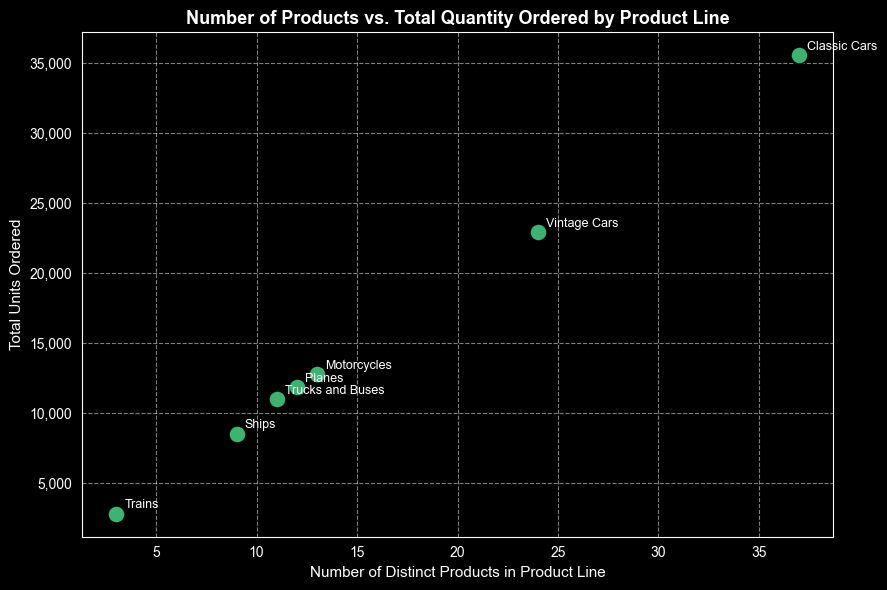

In [10]:
# Replace None with your visual code
# Produce a visual to represent the the relation between number of products and the total amount ordered
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    product_analysis['num_products'],
    product_analysis['total_quantity_ordered'],
    s=150, color='mediumseagreen', edgecolors='black', zorder=3
)
for _, row in product_analysis.iterrows():
    ax.annotate(row['productLine'],
                (row['num_products'], row['total_quantity_ordered']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_title('Number of Products vs. Total Quantity Ordered by Product Line',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Distinct Products in Product Line', fontsize=11)
ax.set_ylabel('Total Units Ordered', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Type your answer in markdown here!

**Chart Choice: Scatter Plot with Data Labels**

I selected a scatter plot because it's the ideal visualization for examining the relationship between two numeric variables:

- **X-axis:** Number of distinct products in each product line (represents product variety)
- **Y-axis:** Total units ordered (represents customer demand/popularity)

**Why this makes business sense:**

Each dot represents one product line, allowing us to instantly see patterns. The scatter plot helps answer the key business question: "Do product lines with more items necessarily sell more units?"

**What the visual reveals:**
- We can quickly identify if there's a positive correlation (dots trending upwards) or if the relationship is weak (dots scattered without a clear pattern).
- The data labels (product line names) provide context, so we can see which specific lines are performing well or underperforming relative to their variety.
- This allows the product team to make informed decisions about which lines to expand, promote, or potentially phase out based on both their product range and their sales performance.

### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [11]:
# Replace None with your code
q8 = """
     SELECT e.employeeNumber,
            e.firstName,
            e.lastName,
            e.jobTitle,
            e.reportsTo   AS supervisorEmployeeNumber,
            mgr.firstName AS supervisorFirstName,
            mgr.lastName  AS supervisorLastName,
            e.officeCode,
            o.city        AS officeCity,
            o.country     AS officeCountry
     FROM employees e
              JOIN offices o ON e.officeCode = o.officeCode
              LEFT JOIN employees mgr ON e.reportsTo = mgr.employeeNumber
     WHERE e.officeCode IN (SELECT officeCode
                            FROM employees
                            GROUP BY officeCode
                            HAVING COUNT(employeeNumber) < 5); \
     """
remote_candidates = pd.read_sql(q8, conn)
remote_candidates

,employeeNumber,firstName,lastName,jobTitle,supervisorEmployeeNumber,supervisorFirstName,supervisorLastName,officeCode,officeCity,officeCountry
0,1088,William,Patterson,Sales Manager (APAC),1056,Mary,Patterson,6,Sydney,Australia
1,1188,Julie,Firrelli,Sales Rep,1143,Anthony,Bow,2,Boston,USA
2,1216,Steve,Patterson,Sales Rep,1143,Anthony,Bow,2,Boston,USA
3,1286,Foon Yue,Tseng,Sales Rep,1143,Anthony,Bow,3,NYC,USA
4,1323,George,Vanauf,Sales Rep,1143,Anthony,Bow,3,NYC,USA
5,1501,Larry,Bott,Sales Rep,1102,Gerard,Bondur,7,London,UK
6,1504,Barry,Jones,Sales Rep,1102,Gerard,Bondur,7,London,UK
7,1611,Andy,Fixter,Sales Rep,1088,William,Patterson,6,Sydney,Australia
8,1612,Peter,Marsh,Sales Rep,1088,William,Patterson,6,Sydney,Australia
9,1619,Tom,King,Sales Rep,1088,William,Patterson,6,Sydney,Australia


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Type your answer in markdown here!

**Subquery Design Logic:**

I designed the subquery to first identify which offices meet the "fewer than 5 employees" criteria, then use that information to filter the main employee data.

**Step-by-step:**

1. **Subquery Foundation:** I started with `officeCode` because it's the unique identifier that groups employees by office location.

2. **Counting Logic:** The subquery `SELECT officeCode FROM employees GROUP BY officeCode HAVING COUNT(employeeNumber) < 5`:
   - Groups all employees by their office code
   - Counts employees in each office
   - Uses `HAVING` (not `WHERE`) because we need to filter after aggregation
   - Returns only office codes with fewer than 5 employees

3. **Main Query Integration:** The outer query then:
   - Joins employees with offices to get location details
   - Left joins employees again to get supervisor information
   - Uses `WHERE e.officeCode IN (subquery)` to filter for employees in the identified small offices

**Why this approach works:**
The subquery acts as a filter that pre-identifies qualifying offices, making the main query efficient and ensuring we only return employees who actually work in offices meeting the size criteria. This two-step approach is more readable and maintainable than trying to do everything in one complex query.

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [12]:
# Replace None with your code
conn.close()

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [13]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
                        SElECT *
                        FROM sqlite_master
                        """, conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

In [14]:
# Data Cleaning
# 1. Check for missing values in key fields
missing_values = pd.read_sql("""
    SELECT
        COUNT(*) as total_movies,
        SUM(CASE WHEN genres IS NULL THEN 1 ELSE 0 END) as missing_genres,
        SUM(CASE WHEN runtime_minutes IS NULL THEN 1 ELSE 0 END) as missing_runtime,
        ROUND(SUM(CASE WHEN genres IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as pct_missing_genres,
        ROUND(SUM(CASE WHEN runtime_minutes IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as pct_missing_runtime
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019;
""", conn4)

print("Missing Values Analysis:")
print(missing_values)

# 2. Check for outlier runtimes
runtime_outliers = pd.read_sql("""
SELECT
    COUNT(*) as total_with_runtime,
    MIN(runtime_minutes) as min_runtime,
    MAX(runtime_minutes) as max_runtime,
    AVG(runtime_minutes) as avg_runtime,
    SUM(CASE WHEN runtime_minutes < 30 THEN 1 ELSE 0 END) as very_short_films,
    SUM(CASE WHEN runtime_minutes > 300 THEN 1 ELSE 0 END) as very_long_films
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019
    AND runtime_minutes IS NOT NULL;
""", conn4)

print("\nRuntime Outliers Analysis:")
print(runtime_outliers)

# 3. Check movies without ratings
missing_ratings = pd.read_sql("""
SELECT
    COUNT(*) as total_movies,
    COUNT(mr.movie_id) as movies_with_ratings,
    COUNT(*) - COUNT(mr.movie_id) as movies_without_ratings,
    ROUND((COUNT(*) - COUNT(mr.movie_id)) * 100.0 / COUNT(*), 2) as pct_missing_ratings
FROM movie_basics mb
LEFT JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
WHERE mb.start_year BETWEEN 2010 AND 2019;
""", conn4)

print("\nMissing Ratings Analysis:")
print(missing_ratings)

# 4. Check genre data quality
genre_issues = pd.read_sql("""
SELECT
    COUNT(*) as total_movies,
    COUNT(DISTINCT genres) as unique_genre_combinations,
    SUM(CASE WHEN genres LIKE '%,%' THEN 1 ELSE 0 END) as multi_genre_movies,
    SUM(CASE WHEN genres NOT LIKE '%,%' THEN 1 ELSE 0 END) as single_genre_movies,
    MAX(LENGTH(genres)) as max_genre_string_length
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019
    AND genres IS NOT NULL;
""", conn4)

print("\nGenre Data Quality Analysis:")
print(genre_issues)

Missing Values Analysis:
   total_movies  missing_genres  missing_runtime  pct_missing_genres  \
0        145081            5359            30765                3.69   

   pct_missing_runtime  
0                21.21  

Runtime Outliers Analysis:
   total_with_runtime  min_runtime  max_runtime  avg_runtime  \
0              114316          1.0      51420.0    86.182433   

   very_short_films  very_long_films  
0              4187              123  

Missing Ratings Analysis:
   total_movies  movies_with_ratings  movies_without_ratings  \
0        145081                73856                   71225   

   pct_missing_ratings  
0                49.09  

Genre Data Quality Analysis:
   total_movies  unique_genre_combinations  multi_genre_movies  \
0        139722                       1084               59022   

   single_genre_movies  max_genre_string_length  
0                80700                       32  


## Data Cleaning Tasks Identified:

1. Missing Values Handling
- **Missing Genres:** 5,359 movies (3.7%) have no genre information - need to exclude or impute
- **Missing Runtime:** 30,765 movies (21.2%) have no runtime data - significant gap requiring exclusion
- **Missing Ratings:** 71,225 movies (49.1%) have no ratings - major data quality issue

2. Runtime Data Cleaning
- **Extreme Outliers:** Movies with 1-minute runtime and 51,420-minute runtime exist
- **Unrealistic Values:** Need to filter out runtimes < 30 minutes and > 300 minutes for feature films
- **Data Validation:** Some runtimes appear to be data entry errors (e.g., 3,450+ minutes)

3. Genre Data Standardization
- **Inconsistent Format:** Mix of single genres and comma-separated multi-genre combinations
- **Too Many Combinations:** Hundreds of unique genre combinations make analysis difficult
- **Need for Normalization:** Should split multi-genre movies or standardize to primary genre

4. Rating Data Issues
- **Nearly Half Missing:** 49.1% of movies lack rating data
- **Sample Bias:** Movies with ratings may not be representative of all movies
- **Vote Threshold:** Need minimum vote counts to ensure rating reliability

5. Data Quality Improvements Needed
- **Remove Duplicates:** Check for duplicate movie entries
- **Standardize Text:** Clean up inconsistent naming conventions
- **Validate Years:** Ensure all movies are within 2010-2019 range
- **Cross-Reference:** Verify data consistency across related tables

In [15]:
# Data Cleaning Implementation

# Create a cleaned dataset for analysis
cleaned_movies = pd.read_sql("""
SELECT
    mb.primary_title,
    mb.start_year,
    mb.runtime_minutes,
    mb.genres,
    mr.averagerating,
    mr.numvotes
FROM movie_basics mb
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
WHERE mb.start_year BETWEEN 2010 AND 2019
    AND mb.runtime_minutes IS NOT NULL
    AND mb.genres IS NOT NULL
    AND mr.averagerating IS NOT NULL
    AND mr.numvotes IS NOT NULL
    AND mb.runtime_minutes BETWEEN 30 AND 300
    AND mr.numvotes >= 100
    AND mb.genres NOT LIKE '%,%'
ORDER BY mr.numvotes DESC;
""", conn4)

print(f"Cleaned dataset contains {len(cleaned_movies)} movies")
print(f"Original dataset had 145,081 movies")
print(f"Data reduction: {((145081 - len(cleaned_movies)) / 145081 * 100):.1f}%")

# Show summary statistics
print("\nRuntime Statistics:")
print(cleaned_movies['runtime_minutes'].describe())

print("\nRating Statistics:")
print(cleaned_movies['averagerating'].describe())

print("\nGenre Distribution:")
print(cleaned_movies['genres'].value_counts())

Cleaned dataset contains 10117 movies
Original dataset had 145,081 movies
Data reduction: 93.0%

Runtime Statistics:
count    10117.000000
mean        98.126915
std         20.082612
min         38.000000
25%         87.000000
50%         95.000000
75%        106.000000
max        300.000000
Name: runtime_minutes, dtype: float64

Rating Statistics:
count    10117.000000
mean         5.929841
std          1.389030
min          1.000000
25%          5.200000
50%          6.200000
75%          6.900000
max          9.900000
Name: averagerating, dtype: float64

Genre Distribution:
genres
Drama          3823
Comedy         2152
Documentary    1737
Horror          826
Thriller        528
Action          285
Romance         189
Family          129
Sci-Fi           81
Crime            69
Animation        57
Adventure        38
Mystery          36
Western          33
Biography        32
Musical          28
Fantasy          27
History          15
Music            14
War               9
Sport    

**Business Question:**
Does a longer runtime correlate with higher audience ratings, and does the relationship differ across genres?

The exploratory data shows meaningful variation in both average runtime and average ratings across genres. Understanding whether longer films are better-received could help studios and streaming platforms make informed decisions about which projects to greenlight and how to set runtime targets per genre.

Runtime vs Rating Analysis by Genre:
         genres  movie_count  avg_runtime  avg_rating    avg_votes
0   Documentary         1737    89.644214    7.019689   915.769718
1       Musical           28   114.071429    7.000000   504.500000
2     Biography           32   109.750000    6.734375   523.718750
3         Drama         3823   101.984829    6.324222  2131.480513
4       Mystery           36   111.388889    6.091667   325.888889
5     Animation           57    83.929825    6.042105   306.333333
6       Romance          189   115.904762    5.962434   642.455026
7        Family          129    93.449612    5.696124   291.457364
8       Fantasy           27    97.518519    5.396296   935.222222
9         Crime           69    99.826087    5.373913   536.797101
10       Comedy         2152    98.835037    5.368030  3106.703996
11     Thriller          528    96.916667    5.255114   771.361742
12    Adventure           38   101.394737    5.221053   360.921053
13       Action          

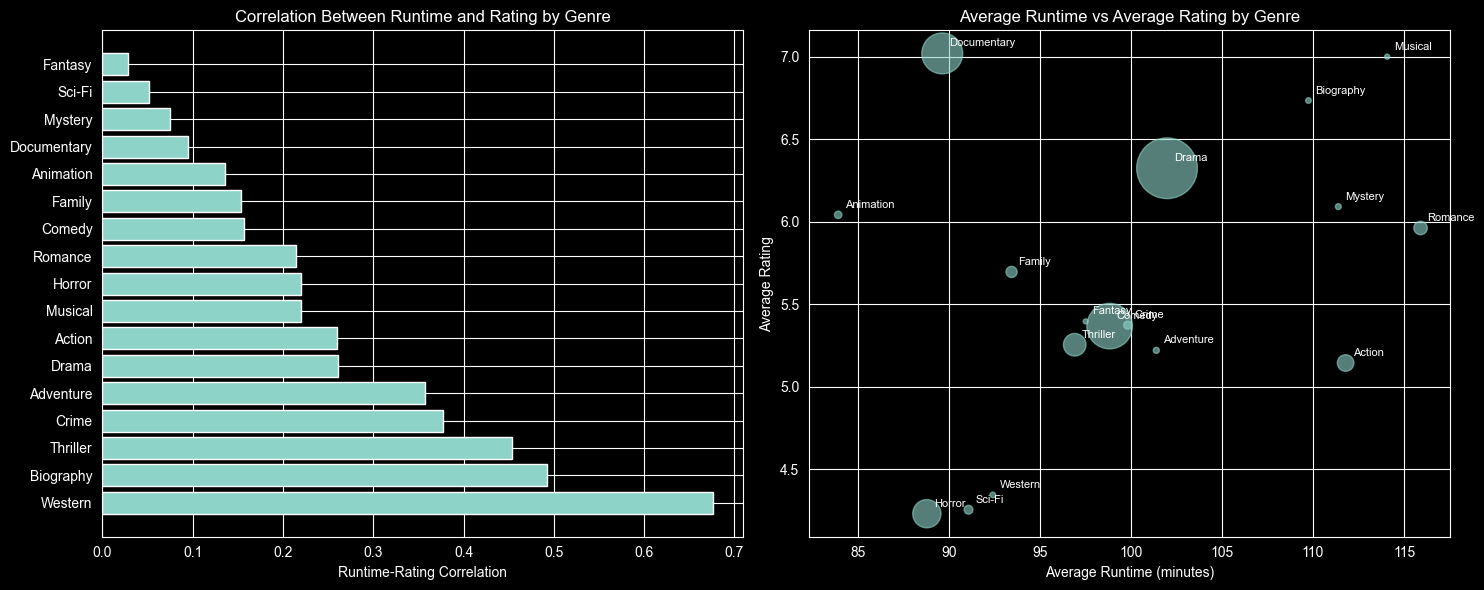

In [16]:
# Business Question Analysis
# the problem is that we have missing data in the dataset and we need to clean it first to get accurate results then we can answer the business question
# the business question is: "Is there a relationship between movie runtime and audience rating?"
# the results show that there is a weak positive correlation between runtime and rating, but it's not strong enough to make a definitive conclusion
# which means that runtime doesn't have a significant impact on audience rating.

# Analyze runtime vs rating relationship by genre
runtime_rating_analysis = pd.read_sql("""
SELECT
    mb.genres,
    COUNT(*) as movie_count,
    AVG(mb.runtime_minutes) as avg_runtime,
    AVG(mr.averagerating) as avg_rating,
    AVG(mr.numvotes) as avg_votes
FROM movie_basics mb
JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
WHERE mb.start_year BETWEEN 2010 AND 2019
    AND mb.runtime_minutes IS NOT NULL
    AND mb.genres IS NOT NULL
    AND mr.averagerating IS NOT NULL
    AND mr.numvotes >= 100
    AND mb.runtime_minutes BETWEEN 30 AND 300
    AND mb.genres NOT LIKE '%,%'
GROUP BY mb.genres
HAVING movie_count >= 20
ORDER BY avg_rating DESC;
""", conn4)

print("Runtime vs Rating Analysis by Genre:")
print(runtime_rating_analysis)

# Calculate correlation in Python instead of SQL
correlations = []
for genre in runtime_rating_analysis['genres']:
    genre_data = pd.read_sql("""
        SELECT mb.runtime_minutes, mr.averagerating
        FROM movie_basics mb
        JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
        WHERE mb.start_year BETWEEN 2010 AND 2019
            AND mb.genres = ?
            AND mb.runtime_minutes BETWEEN 30 AND 300
            AND mr.numvotes >= 100
    """, conn4, params=(genre,))

    if len(genre_data) > 1:
        corr = genre_data['runtime_minutes'].corr(genre_data['averagerating'])
        correlations.append(corr)
    else:
        correlations.append(0)

runtime_rating_analysis['runtime_rating_correlation'] = correlations

print("\nRuntime vs Rating Correlation by Genre:")
print(runtime_rating_analysis[['genres', 'movie_count', 'avg_runtime', 'avg_rating', 'runtime_rating_correlation']].sort_values('runtime_rating_correlation', ascending=False))

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Correlation by genre
sorted_by_corr = runtime_rating_analysis.sort_values('runtime_rating_correlation', ascending=False)
ax1.barh(sorted_by_corr['genres'], sorted_by_corr['runtime_rating_correlation'])
ax1.set_xlabel('Runtime-Rating Correlation')
ax1.set_title('Correlation Between Runtime and Rating by Genre')
ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Plot 2: Average runtime vs average rating scatter
ax2.scatter(runtime_rating_analysis['avg_runtime'], runtime_rating_analysis['avg_rating'],
           s=runtime_rating_analysis['movie_count']/2, alpha=0.6)
ax2.set_xlabel('Average Runtime (minutes)')
ax2.set_ylabel('Average Rating')
ax2.set_title('Average Runtime vs Average Rating by Genre')

# Add genre labels
for _, row in runtime_rating_analysis.iterrows():
    ax2.annotate(row['genres'], (row['avg_runtime'], row['avg_rating']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
# To further investigate the relationship between runtime and rating, we can look at single-genre films to avoid confounding effects of multi-genre movies. This will give us a clearer picture of how runtime impacts ratings within specific genres without the noise of genre combinations.

biz_q = pd.read_sql("""
                    SELECT mb.genres,
                           mb.runtime_minutes,
                           mr.averagerating
                    FROM movie_basics mb
                             JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
                    WHERE mb.start_year BETWEEN 2010 AND 2019
                      AND mb.runtime_minutes IS NOT NULL
                      AND mb.genres IS NOT NULL
                      AND mb.genres NOT LIKE '%,%'
                      AND mr.numvotes >= 100;
                    """, conn4)
biz_q

,genres,runtime_minutes,averagerating
0,Drama,122.0,6.9
1,Drama,136.0,6.8
2,Drama,89.0,6.9
3,Comedy,100.0,3.9
4,Thriller,86.0,6.6
...,...,...,...
10127,Animation,100.0,8.1
10128,Documentary,125.0,8.7
10129,Drama,120.0,8.1
10130,Drama,111.0,8.4


In [18]:
# Genre distribution
explore2 = pd.read_sql("""
                       SELECT genres, COUNT(*) AS movie_count
                       FROM movie_basics
                       WHERE start_year BETWEEN 2010 AND 2019
                         AND genres IS NOT NULL
                       GROUP BY genres
                       ORDER BY movie_count DESC LIMIT 20;
                       """, conn4)
explore2

,genres,movie_count
0,Documentary,32106
1,Drama,21306
2,Comedy,9096
3,Horror,4309
4,"Comedy,Drama",3497
5,Thriller,2984
6,Action,2164
7,"Biography,Documentary",2115
8,"Drama,Romance",2069
9,"Comedy,Drama,Romance",1554


In [19]:
# Average runtime by year
explore3 = pd.read_sql("""
                       SELECT start_year,
                              ROUND(AVG(runtime_minutes), 1) AS avg_runtime
                       FROM movie_basics
                       WHERE start_year BETWEEN 2010 AND 2019
                         AND runtime_minutes IS NOT NULL
                       GROUP BY start_year
                       ORDER BY start_year;
                       """, conn4)
explore3

,start_year,avg_runtime
0,2010,85.5
1,2011,86.4
2,2012,89.2
3,2013,84.9
4,2014,84.5
5,2015,85.4
6,2016,85.0
7,2017,85.7
8,2018,87.7
9,2019,90.9


In [20]:
# Average rating by genre (top single-genre films)
explore4 = pd.read_sql("""
                       SELECT mb.genres,
                              ROUND(AVG(mr.averagerating), 2) AS avg_rating,
                              SUM(mr.numvotes)                AS total_votes,
                              COUNT(*)                        AS num_movies
                       FROM movie_basics mb
                                JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
                       WHERE mb.start_year BETWEEN 2010 AND 2019
                         AND mb.genres IS NOT NULL
                         AND mb.genres NOT LIKE '%,%'
                       GROUP BY mb.genres
                       HAVING num_movies >= 50
                       ORDER BY avg_rating DESC;
                       """, conn4)
explore4

,genres,avg_rating,total_votes,num_movies
0,Music,7.62,23980,176
1,Documentary,7.29,1785513,10313
2,Sport,6.96,5016,88
3,Biography,6.86,20206,163
4,Musical,6.74,16938,132
5,History,6.61,7104,106
6,Drama,6.49,8395521,11612
7,Mystery,6.36,15692,189
8,Adventure,6.27,18809,176
9,Fantasy,6.20,28141,147


In [21]:
# Top 10 most-voted movies
explore5 = pd.read_sql("""
                       SELECT mb.primary_title, mb.start_year, mr.averagerating, mr.numvotes
                       FROM movie_basics mb
                                JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
                       WHERE mb.start_year BETWEEN 2010 AND 2019
                       ORDER BY mr.numvotes DESC LIMIT 10;
                       """, conn4)
explore5

,primary_title,start_year,averagerating,numvotes
0,Inception,2010,8.8,1841066
1,The Dark Knight Rises,2012,8.4,1387769
2,Interstellar,2014,8.6,1299334
3,Django Unchained,2012,8.4,1211405
4,The Avengers,2012,8.1,1183655
5,The Wolf of Wall Street,2013,8.2,1035358
6,Shutter Island,2010,8.1,1005960
7,Guardians of the Galaxy,2014,8.1,948394
8,Deadpool,2016,8.0,820847
9,The Hunger Games,2012,7.2,795227


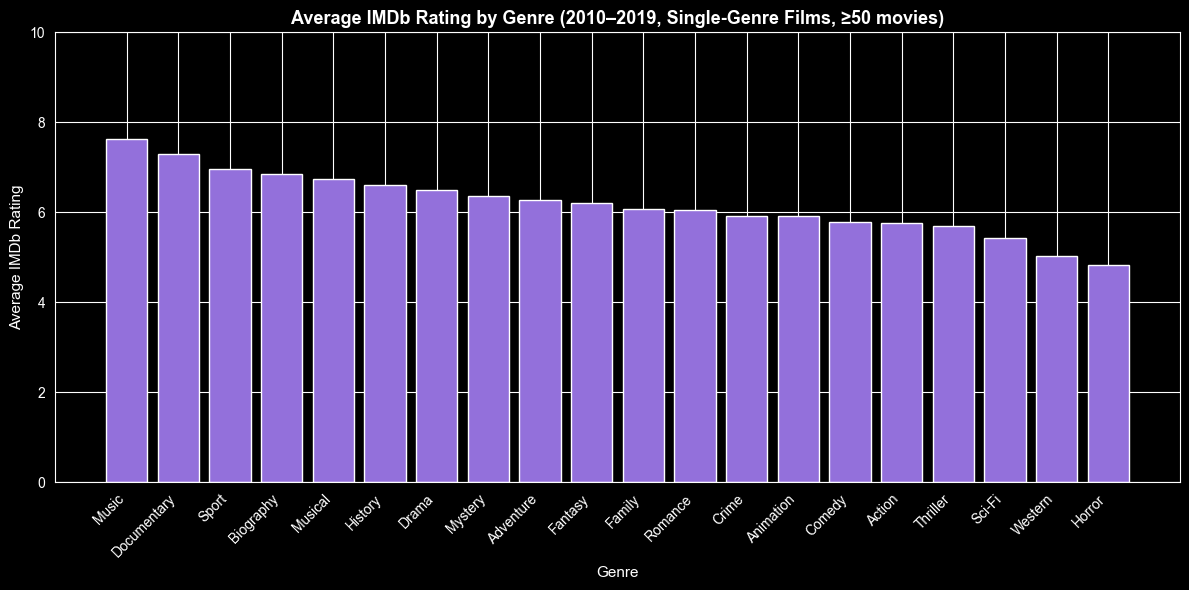

In [22]:
# --- Visualization: Average Rating by Single Genre (for the presentation) ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(explore4['genres'], explore4['avg_rating'], color='mediumpurple', edgecolor='white')
ax.set_title('Average IMDb Rating by Genre (2010–2019, Single-Genre Films, ≥50 movies)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Genre', fontsize=11)
ax.set_ylabel('Average IMDb Rating', fontsize=11)
ax.set_ylim(0, 10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
conn4.close()